# Demo 7 (PE): Analyzing Keypoint Movement and Kinematics in Pose Estimation Data

*Written and last updated September 18, 2025 by Sedona Ewbank, snewbank@stanford.edu*

The purpose of this demo is to demonstrate how to measure and plot keypoint travel and ego-centered kinematics in pose estimation data types typically associated with animal experiments (DLC, SLEAP) in MARIPoSA.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML

#This block only important for running as script
#script_dir = os.path.dirname(os.path.abspath(__file__))
mariposa_dir = "/Users/snewbank/PycharmProjects/MARIPoSA"
utils_dir = os.path.join(mariposa_dir, 'utils')
sys.path.append(utils_dir)
sys.path.append(mariposa_dir)

#import utils
from utils import metadata, analyze, plot, simulate

importlib.reload(metadata)
importlib.reload(analyze)
importlib.reload(plot)
importlib.reload(simulate)

<module 'utils.simulate' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py'>

In [2]:
demo_dir="/Users/snewbank/Behavior/MARIPoSA_demo_data/"
config=metadata.load_project(demo_dir+"250910_test_PE/config_PE.yaml")
save=True
save_path = demo_dir+"demo_figures/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

## 7.1: Measuring and plotting keypoint travel in animals

The purpose of this mode of analysis is to measure how much a keypoint has travelled during a recording, with or without time binning. This could reflect locomotion (e.g., in an open field recording approach) or overall movement of a keypoint in a confined assay (e.g., a reaching task). We obtain this with analyze.get_keypoint_travel, which will return a KeypointTravel object that we can then use for further analysis. Note the threshold parameter of this function, which optionally "cleans" the data; it can be disabled by setting it to None.

In [3]:
help(analyze.get_keypoint_travel)

Help on function get_keypoint_travel in module utils.analyze:

get_keypoint_travel(PE_config, keypoint, start, end, binsize=None, thresh=70, selected_subgroups='all', return_as_df=True)
    Measure keypodint distance travelled across group of subjects
    
    :param PE_config: pose estimation config - used for FPS only
    :param keypoint: name of keypoint
    :param start: start time in seconds
    :param end: end time in seconds
    :param binsize: if binned output is desired, size of timebins (default is None for no binning)
    :param thresh: threshold for when distance 'jump' is too large and should be excluded; default 70
    :param selected_subgroups: subgroups to analyze as defined in config; default "all"
    :param return_as_df: return as a dataframe or return as KeypointTravel class (for embedding, classification)
    :return:



,0.0,group
2023-06-15_21-28-12_bf04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,76585.673549,sal
2023-06-15_22-01-50_bf03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,77601.985038,sal
2023-06-20_15-41-01_bm03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,21844.904953,sal
2023-06-20_16-13-48_bm04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,46279.020517,sal
2023-06-20_17-21-51_bf02_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,69155.547166,sal
2023-07-03_16-15-21_bm02_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,60179.625151,sal
2023-07-03_19-20-49_bf01_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,74034.204420,sal
2023-06-20_19-10-38_bf04_k1ivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,88946.845156,k1
2023-06-26_15-35-45_bf01_k1ivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,85649.979937,k1
2023-06-26_19-00-05_bm02_k1ivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,92955.598550,k1


,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,group
2023-06-15_21-28-12_bf04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,8880.331395,3351.100258,1587.052168,2750.742715,6399.252095,3460.315582,1016.990993,2570.881432,5468.918087,6059.387430,...,1104.964260,1500.049482,3898.298124,6544.453556,4779.386395,3759.273735,2990.124814,1878.317699,6675.841174,sal
2023-06-15_22-01-50_bf03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,8071.237357,6181.385243,7522.841487,3543.876735,3620.211232,5351.320313,6009.554638,3952.848740,5135.739960,2218.138347,...,2122.939566,2672.667907,4010.858900,3015.353875,1996.782716,2114.914108,2257.268367,2296.118505,2669.904618,sal
2023-06-20_15-41-01_bm03_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,2660.048643,1383.006506,1059.346533,1503.847833,1535.395087,1002.214252,1054.906797,1108.866013,998.275640,1074.835503,...,929.709634,910.307825,925.516701,768.447314,859.197324,803.552190,912.919929,705.072034,681.108369,sal
2023-06-20_16-13-48_bm04_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,5485.073029,1319.469199,3407.583833,3389.185426,2014.415106,2541.982760,2881.827623,2246.780758,3373.222174,1624.433605,...,2263.354499,2712.941823,1787.785253,2965.370830,1906.642921,792.458697,1058.076463,1420.924233,1579.055731,sal
2023-06-20_17-21-51_bf02_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,7938.195203,6110.713672,5439.324565,4607.947223,3910.104986,3904.234479,3953.831284,4420.781394,2795.601820,2183.251945,...,1217.639745,1699.270851,1403.652257,5089.822149,4489.189921,1268.897918,1459.432966,1557.146247,3414.117895,sal
2023-07-03_16-15-21_bm02_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,7048.375661,5818.277145,5278.729134,6021.514273,4386.361838,4524.004535,2291.139233,1999.318602,4098.064644,1537.187124,...,3163.314795,1602.690430,1330.173334,1244.696870,1295.699150,1398.134903,1399.431639,1282.853249,1105.019397,sal
2023-07-03_19-20-49_bf01_salivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,8241.668408,4963.881674,5521.215270,3499.214739,3161.170596,5903.910838,3711.337363,2840.721863,4470.272583,4842.918753,...,2164.682111,2000.644887,1889.692155,3446.230399,3064.598552,2689.005167,2111.795295,2750.955661,1497.574769,sal
2023-06-20_19-10-38_bf04_k1ivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,8845.988403,7188.888682,8933.440687,7737.247830,7132.427277,5154.259105,6499.133309,4838.891810,4362.034290,7835.191761,...,1406.535741,1084.069936,1088.998064,1959.846857,1817.340613,1521.430826,1497.603369,3469.641220,2591.058581,k1
2023-06-26_15-35-45_bf01_k1ivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,11838.689804,8031.028128,8091.465003,4083.950757,6227.053949,8353.814333,6247.864234,4675.471830,1606.425168,3986.807139,...,1737.062475,2822.933304,2976.058980,3062.887893,2957.368912,1436.065023,1788.045139,1733.746204,1242.606624,k1
2023-06-26_19-00-05_bm02_k1ivDLC_resnet101_DevRats2Jul21shuffle1_500000.csv,20724.839634,10159.438676,6694.307894,5773.045308,5343.981806,3339.687841,2991.561963,4323.656226,4578.547308,1474.808605,...,1333.393782,2728.749019,1169.581962,2477.143336,4004.994848,2404.780803,3424.785899,4033.969786,4708.006492,k1


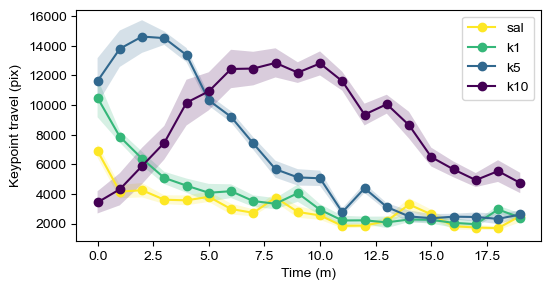

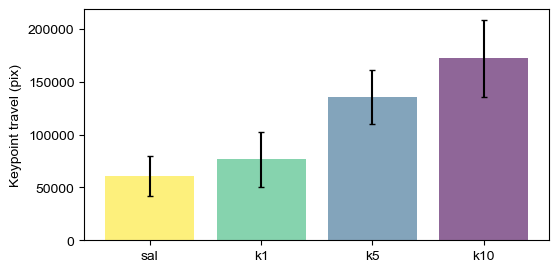

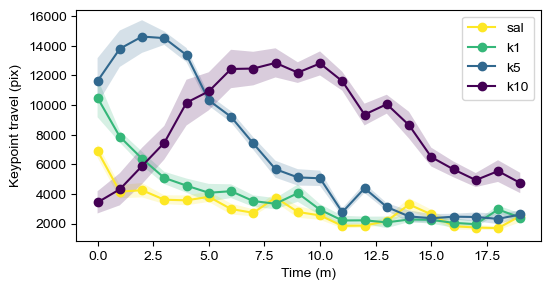

In [4]:
kp_travel = analyze.get_keypoint_travel(config,
                                        "tailbase",
                                        0,1200,
                                        selected_subgroups=["sal","k1","k5","k10"],
                                        return_as_df=False)

kp_travel_df = kp_travel.to_df()
display(kp_travel_df)
plot.plot_keypoint_travel(kp_travel,cmap="viridis_r",plottype="bar")

kp_travel = analyze.get_keypoint_travel(config,
                                        "tailbase",
                                        0,1200,
                                        binsize=60,
                                        selected_subgroups=["sal","k1","k5","k10"],
                                        return_as_df=False)

kp_travel_df = kp_travel.to_df()
display(kp_travel_df)
plot.plot_keypoint_travel(kp_travel,cmap="viridis_r")

## 7.2 Using keypoint travel in animals for embedding and classification
The KeypointTravel class has many of the same attributes and use cases as pose segmentation data object classes (ModuleUsage and ModuleTransitions), and thus we can use the same embedding, classification, and regression functions as we do for pose segmentation data. 
It is worth noting that travel of a single keypoint only has sufficient dimensionality for some methods (e.g., PCA) if time binning is applied, otherwise it is a point value rather than a time series.
We can start by looking at embedding the data with PCA or LDA.

Ellipse only drawn for embeddings_object of class LDA, not <class 'sklearn.decomposition._pca.PCA'>


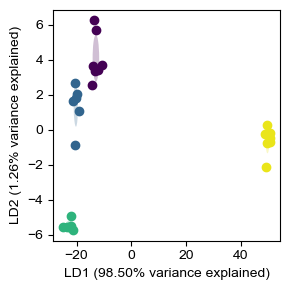

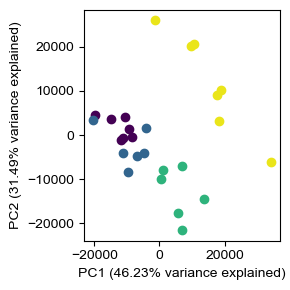

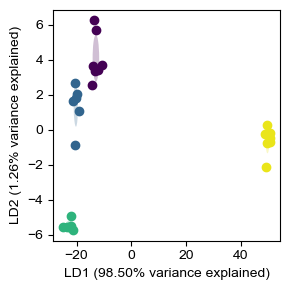

In [5]:
pca_emb = analyze.embed(kp_travel,method="pca")
plot.plot_embeddings(kp_travel,pca_emb)
lda_emb = analyze.embed(kp_travel,method="lda")
plot.plot_embeddings(kp_travel,lda_emb)

Next, we can look at classification with logistic regression - here shown with training a classifier on the full dataset and leave-one-out cross-validation to test performance on a subset of samples.

/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

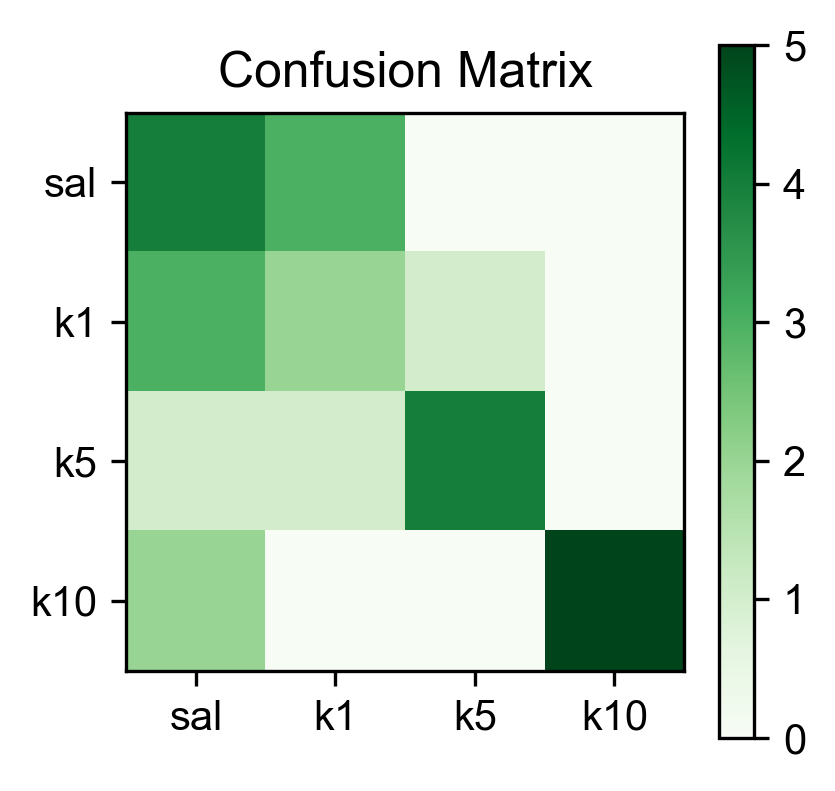

In [6]:
clf = analyze.classify(kp_travel,method="LogisticRegression")
accuracy, conf_mat = analyze.loocv(kp_travel,method="LogisticRegression")
plt.figure(figsize=(3,3),dpi=300)
plt.imshow(conf_mat,cmap="Greens")
plt.xticks([0,1,2,3],labels=kp_travel.group_dict.keys())
plt.yticks([0,1,2,3],labels=kp_travel.group_dict.keys())
plt.title("Confusion Matrix")
plt.colorbar()

And now we can take a look at using regression on a KeypointTravel class object.

Text(0, 0.5, 'Predicted dose (mg/kg)')

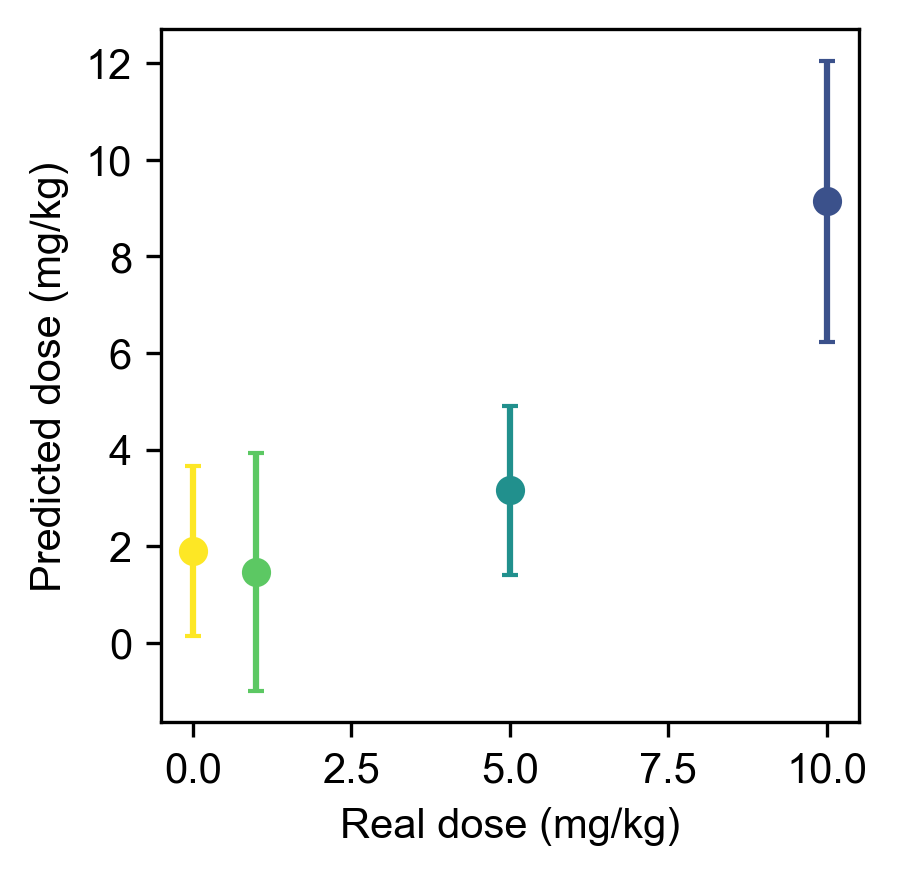

In [7]:
# Training regression model and doing LOOCV
dose_dict={"sal":0,"k1":1,"k5":5,"k10":10}
reg, dose_labels = analyze.regress(kp_travel,dose_dict)
y_preds, sq_err = analyze.loocv_regression(kp_travel,dose_dict)

# Plotting results for held-out samples
plt.figure(figsize=(3,3),dpi=300)
cmap = "viridis_r"
cmap = plt.get_cmap(cmap)
colors = [cmap([i/4]) for i in range(4)]
for d,dose in enumerate(dose_dict.keys()):
    x = dose_dict[dose]
    mask = np.array(kp_travel.group_labels)==kp_travel.group_dict[dose]
    m = np.mean(y_preds[mask])
    sd = np.std(y_preds[mask])
    plt.errorbar(x,m,yerr=sd,linestyle="none",marker="o",color=colors[d],capsize=2)
plt.xlabel("Real dose (mg/kg)")
plt.ylabel("Predicted dose (mg/kg)")

## 7.3: Measuring and using ego-centered kinematics from pose estimation data
Travel of a single keypoint of interest can be useful for measuring overall movement of the animal or limb, depending on the experimental setup; however, additional insight can be gained by ego-centering the data (i.e., using two keypoints to establish the origin and axis along which to reorient all points to) and evaluating the angle, location, and movement of keypoints relative to the new orientation. Ego-centering is acheived in MARIPoSA with analyze.ego_center(), which may be useful to know if you want to save the ego-centered data for some reason. Below is the documentation for analyze.ego_center and a movie plotting the original and ego-centered data.

In [8]:
help(analyze.ego_center)

Help on function ego_center in module utils.analyze:

ego_center(config, data, keypoint_ego1, keypoint_ego2)
    Ego centering a single pose estimation dataframe
    
    :param config: config
    :param data: pose estimation pandas dataframe in DLC format
    :param keypoint_ego1: first keypoint to use for establishing egocentric alignment axis
    :param keypoint_ego2: second keypoint to use for establishing egocentric alignment axis
    :return: ego_centered pandas dataframe



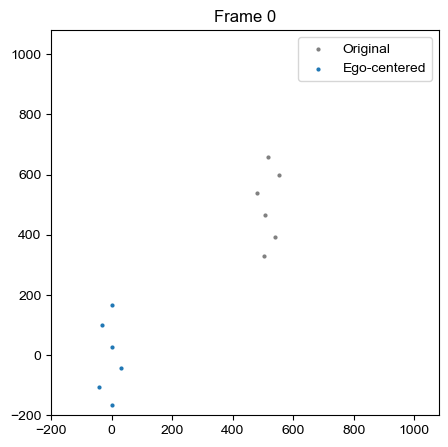

In [9]:
data = pd.read_csv(config["data_directory"]+config["project_files"][0],header=[1,2])
data_reoriented = analyze.ego_center(config, data, "tailbase", "nose")

fig, ax = plt.subplots(figsize=(5, 5))

def update(fr):
    ax.clear()
    x = data.xs("x", level=1, axis=1).loc[fr]
    y = data.xs("y", level=1, axis=1).loc[fr]
    x_ego = data_reoriented.xs("x", level=1, axis=1).loc[fr]
    y_ego = data_reoriented.xs("y", level=1, axis=1).loc[fr]
    
    ax.scatter(x, y, color="gray", s=4, label="Original")
    ax.scatter(x_ego, y_ego, color="C0", s=4, label="Ego-centered")
    ax.set_xlim([-200, 1080])
    ax.set_ylim([-200, 1080])
    ax.set_title(f"Frame {fr}")
    ax.legend(loc="upper right")

nframes=300
ani = FuncAnimation(fig, update, frames=nframes, interval=50)
HTML(ani.to_jshtml())

Ego-centering is incorporated into the function analyze.get_keypoint_kinematics, which can get the angle, distance, or travel/movement of keypoints relative to the ego-center.

In [10]:
help(analyze.get_keypoint_kinematics)

Help on function get_keypoint_kinematics in module utils.analyze:

get_keypoint_kinematics(PE_config, keypoint_ego1, keypoint_ego2, start, end, binsize=None, metric='angle', thresh=70, selected_subgroups='all', return_as_df=True, verbose=False)
    Measure keypoint kinematics (egocentrically aligned angle, distance, and travel of keypoints) across group of subjects
    
    :param PE_config: pose estimation config - used for FPS only
    :param keypoint1: first keypoint to use for establishing egocentric alignment axis
    :param keypoint2: second keypoint to use for establishing egocentric alignment axis
    :param start: start time in seconds
    :param end: end time in seconds
    :param binsize: if binned output is desired, size of timebins (default is None for no binning)
    :param metric: metric to assess for all non-keypoint1/2 keypoints; must be "angle", "distance", or "travel"
    :param thresh: threshold for when distance 'jump' is too large and should be excluded; default 7

Accuracy: 0.23076923076923078


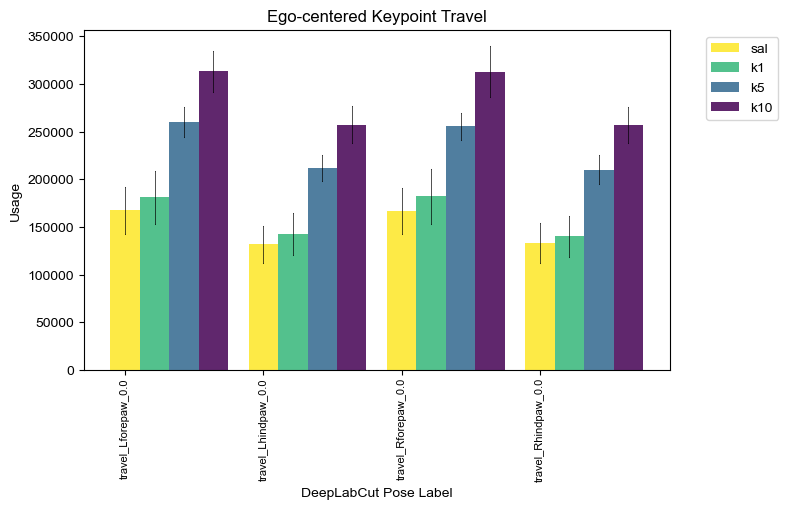

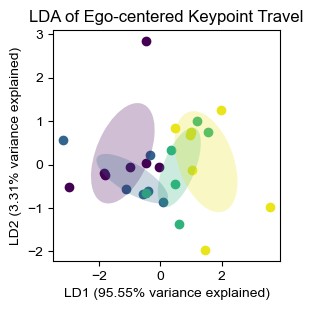

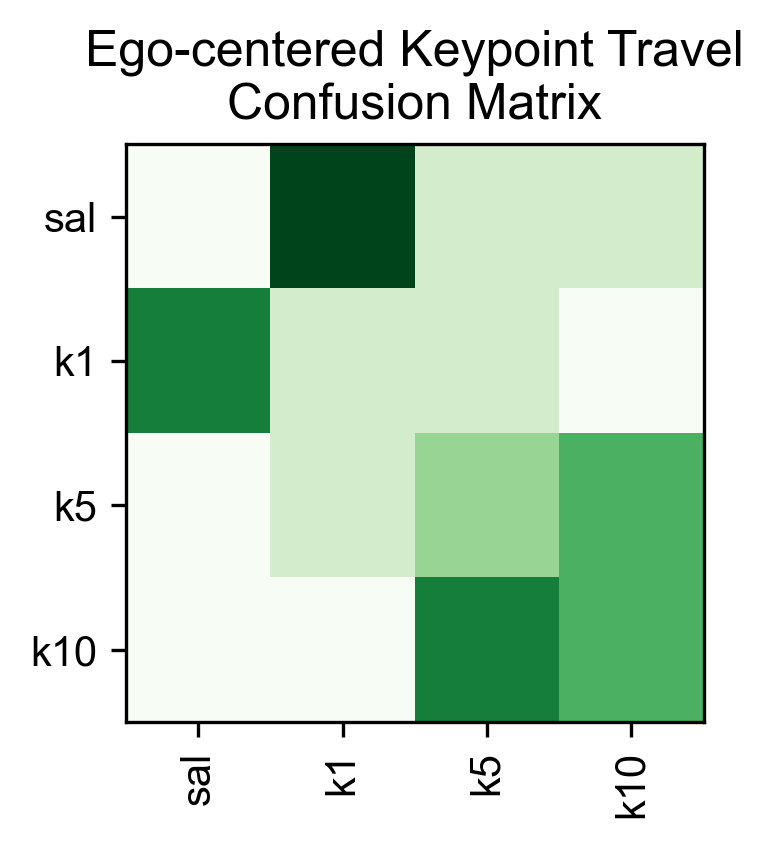

In [11]:
# Get the kinematic data - travel of keypoints relative to egocentric axis
travel_kin = analyze.get_keypoint_kinematics(config,
                                             "tailbase",
                                             "nose",
                                             0, 1200,
                                             metric='travel',
                                             selected_subgroups=['sal', 'k1', 'k5', 'k10'],
                                             return_as_df=False)

# plot the ego-centered travel data
plot.plot_module_usage(config,travel_kin, figH=5,figW=8,style="bar_error",cmap="viridis_r")
plt.title("Ego-centered Keypoint Travel")

# use the data for embedding and classification
emb = analyze.embed(travel_kin)
plot.plot_embeddings(travel_kin,emb)
plt.title("LDA of Ego-centered Keypoint Travel")
plt.figure(figsize=(2.5,2.5),dpi=300)
plt.title("Ego-centered Keypoint Travel\nConfusion Matrix")
acc, cm = analyze.loocv(travel_kin)
plt.imshow(cm,cmap="Greens")
ticklabels=['sal','k1','k5','k10']
plt.xticks(range(len(ticklabels)),labels=ticklabels,rotation=90)
plt.yticks(range(len(ticklabels)),labels=ticklabels)
print(f"Accuracy: {acc}")

Accuracy: 0.11538461538461539


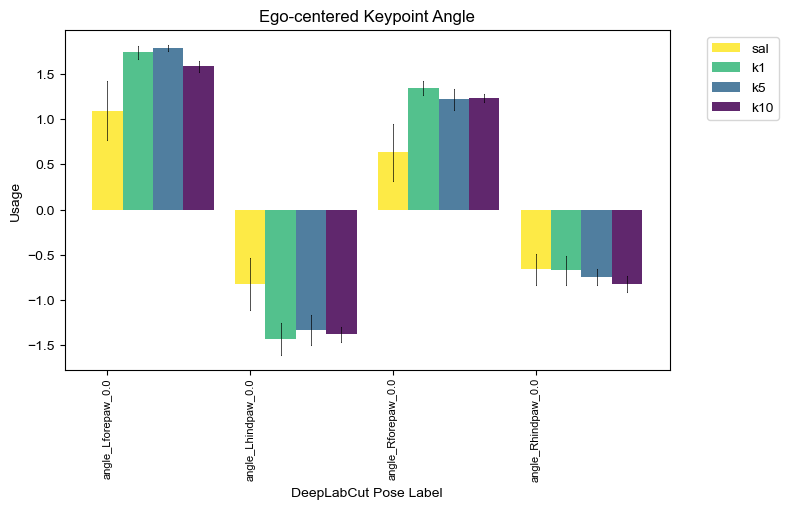

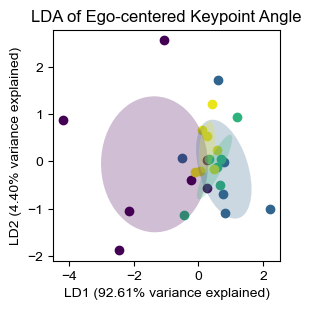

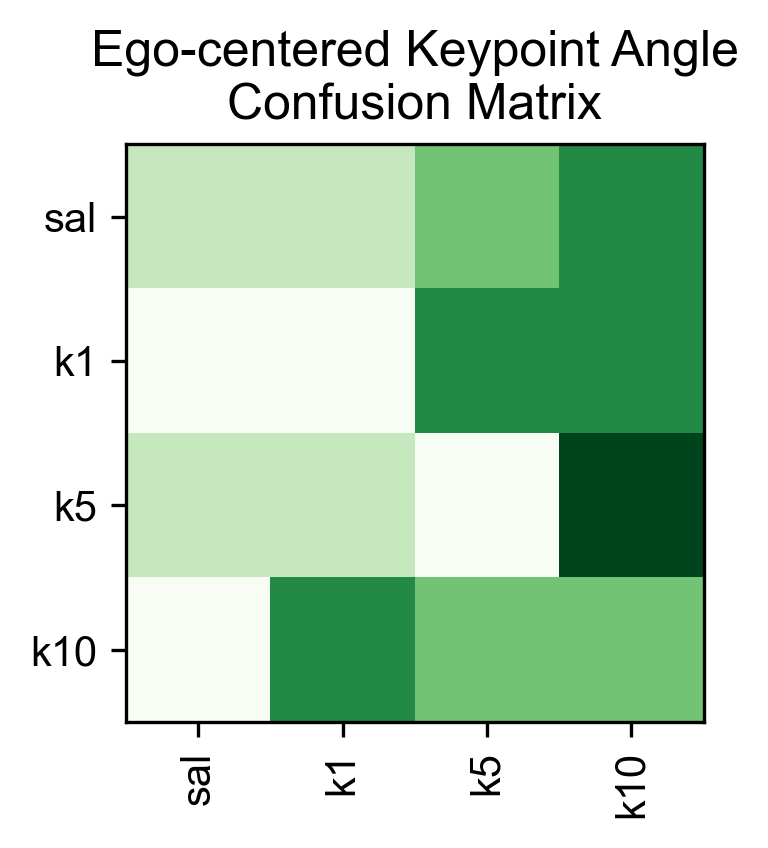

In [12]:
# Get the kinematic data - angle of keypoints relative to egocentric axis
angle_kin = analyze.get_keypoint_kinematics(config,
                                             "tailbase",
                                             "nose",
                                             0, 1200,
                                             metric='angle',
                                             selected_subgroups=['sal', 'k1', 'k5', 'k10'],
                                             return_as_df=False)

# plot the kinematic data
plot.plot_module_usage(config,angle_kin, figH=5,figW=8,style="bar_error",cmap="viridis_r")
plt.title("Ego-centered Keypoint Angle")

# use the data for embedding and classification
emb = analyze.embed(angle_kin)
plot.plot_embeddings(angle_kin,emb)
plt.title("LDA of Ego-centered Keypoint Angle")
plt.figure(figsize=(2.5,2.5),dpi=300)
plt.title("Ego-centered Keypoint Angle\nConfusion Matrix")
acc, cm = analyze.loocv(angle_kin)
plt.imshow(cm,cmap="Greens")
ticklabels=['sal','k1','k5','k10']
plt.xticks(range(len(ticklabels)),labels=ticklabels,rotation=90)
plt.yticks(range(len(ticklabels)),labels=ticklabels)
print(f"Accuracy: {acc}")